# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [2]:
#Set the limit for showing colums in dataset
pd.set_option('display.max_columns', 200)

In [33]:
#Read the dataset with pandas
df_begin = pd.read_csv('healthcare-dataset-stroke-data.csv', index_col = 0)
df_begin = df_begin.reset_index(drop=True)
df_begin

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# EDA, Data Cleaning and Feature Engineering


## I. Dataset Overview

In [34]:
print('The information about dataset:')
df_begin.info()

The information about dataset:
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 594.7 KB


In [35]:
print('Statictis from dataset:')
df_begin.describe()

Statictis from dataset:


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
print('Size of dataset:')
df_begin.shape

Size of dataset:


(5110, 11)

In [ ]:
print('All colums in dataset:')
df_begin.columns

All colums in dataset:


Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [36]:
df_begin.columns = df_begin.columns.str.replace("_", " ").str.title()
df_begin.head()

,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## II. Check Missing Values and Duplicated values

In [ ]:
# Check duplicate value
duplicate_sum = int(df_begin.duplicated().sum())
print('Duplicated Value in dataset:', duplicate_sum)

Duplicated Value in dataset: 0


In [ ]:
# Check missing values
print('Missing Value in dataset:')
df_begin.isna().sum()

Missing Value in dataset:


,0
Gender,0
Age,0
Hypertension,0
Heart Disease,0
Ever Married,0
Work Type,0
Residence Type,0
Avg Glucose Level,0
Bmi,201
Smoking Status,0


### This data has 201 missing value of BMI. We will use fillna() to fix them

In [ ]:
# Check skewness of Bmi feature
df_begin['Bmi'].skew()

np.float64(1.0553402052962912)

#### => Bmi's skew higher than 1 so we will fill missing value of Bmi feature by median

In [37]:
# fillna
df_begin['Bmi'] = df_begin['Bmi'].fillna(df_begin['Bmi'].median())

In [ ]:
#Check missing value after fillnan
df_begin.isna().sum()

,0
Gender,0
Age,0
Hypertension,0
Heart Disease,0
Ever Married,0
Work Type,0
Residence Type,0
Avg Glucose Level,0
Bmi,0
Smoking Status,0


In [ ]:
df_begin.head()

,Gender,Age,Hypertension,Heart Disease,Ever Married,Work Type,Residence Type,Avg Glucose Level,Bmi,Smoking Status,Stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## III. Check unique values

Percentage of people who have had a stroke compared to those who have not: Stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


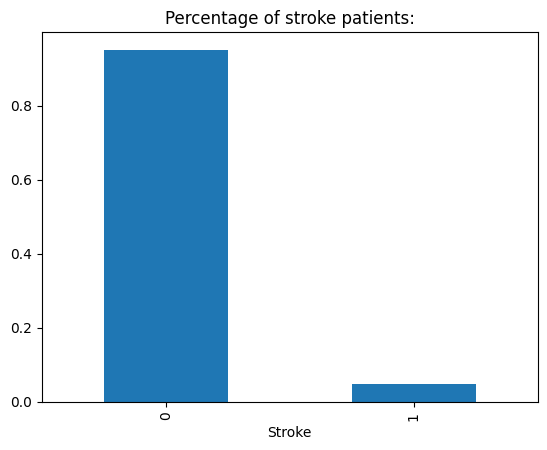

In [ ]:
# visualize label with plot
print('Percentage of people who have had a stroke compared to those who have not:',
      df_begin['Stroke'].value_counts(normalize=True))
df_begin['Stroke'].value_counts(normalize=True).plot(kind='bar')
plt.title('Percentage of stroke patients:')
plt.show()

#### => Looking at the chart, the number of people who did not suffer a stroke is lower than the other group which more than approximately 91%
### => Data imbalance

In [38]:
# Check unique value of gender
df_begin['Gender'].value_counts()

Gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

=> The dataset has 1 row where gender is other. With the lowest number, we can remove to have a cleaning dataset

In [39]:
df_begin = df_begin[df_begin['Gender'] != 'Other'].reset_index(drop=True)
print('After removing "Gender = Other":', df_begin.shape)

After removing "Gender = Other": (5109, 11)


In [40]:
# check unique value of work type
df_begin['Work Type'].value_counts()

Work Type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [ ]:
# check unique value of work type
df_begin['Smoking Status'].value_counts()

,count
Smoking Status,
never smoked,1892
Unknown,1544
formerly smoked,884
smokes,789


## IV. Univariate Analysis

In [ ]:
df_begin.columns

Index(['Gender', 'Age', 'Hypertension', 'Heart Disease', 'Ever Married',
       'Work Type', 'Residence Type', 'Avg Glucose Level', 'Bmi',
       'Smoking Status', 'Stroke'],
      dtype='object')

In [ ]:
# Separate data for visualizing
categorical_cols = ['Gender', 'Ever Married', 'Work Type', 'Residence Type', 'Smoking Status']

numerical_cols = ['Age', 'Avg Glucose Level', 'Bmi']

binary_cols = ['Hypertension', 'Heart Disease']

### Visualize the categorical data

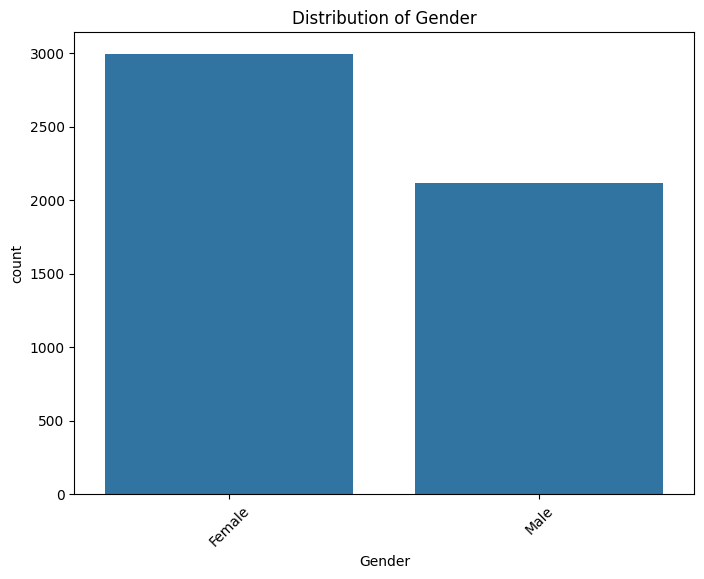

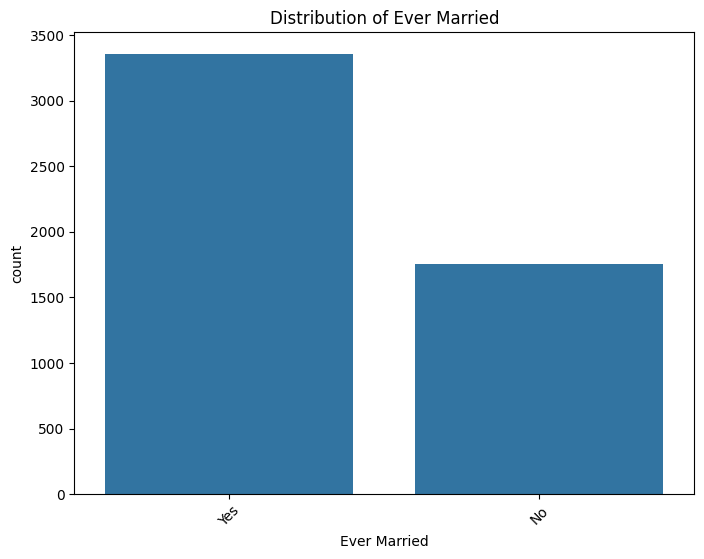

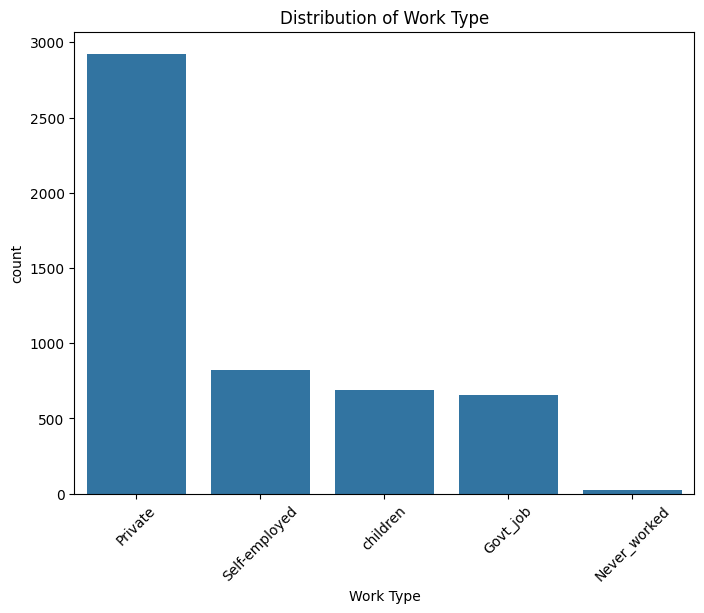

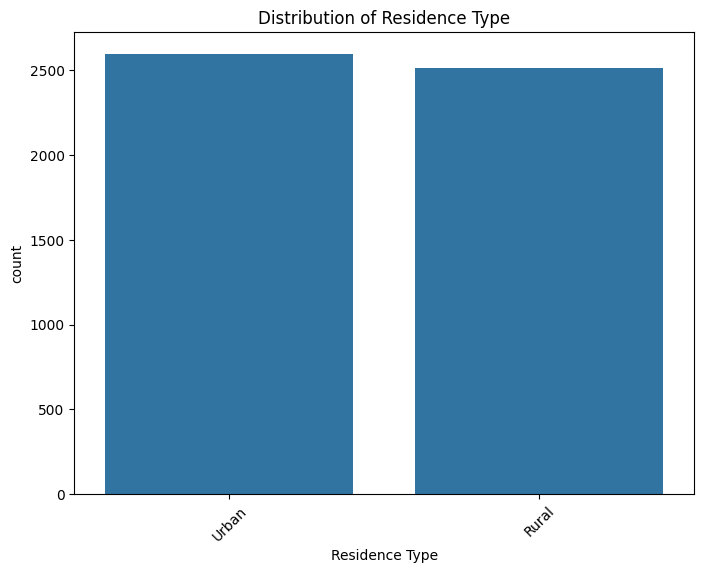

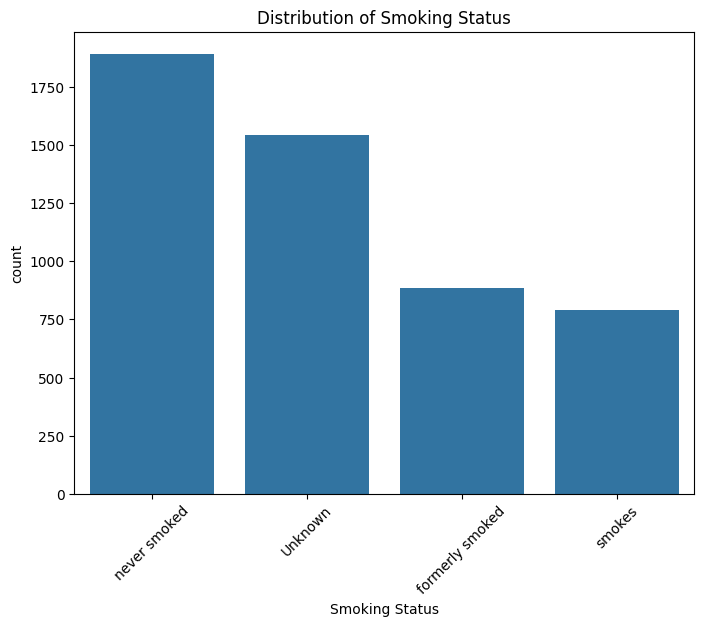

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8,6))

    sns.countplot(
        x = df_begin [col],
        order = df_begin[col].value_counts().index
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()


### Visualize the numerical data

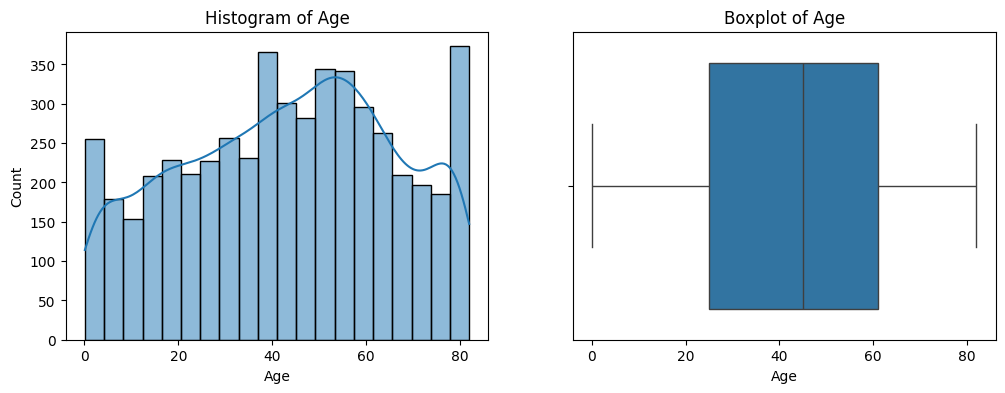

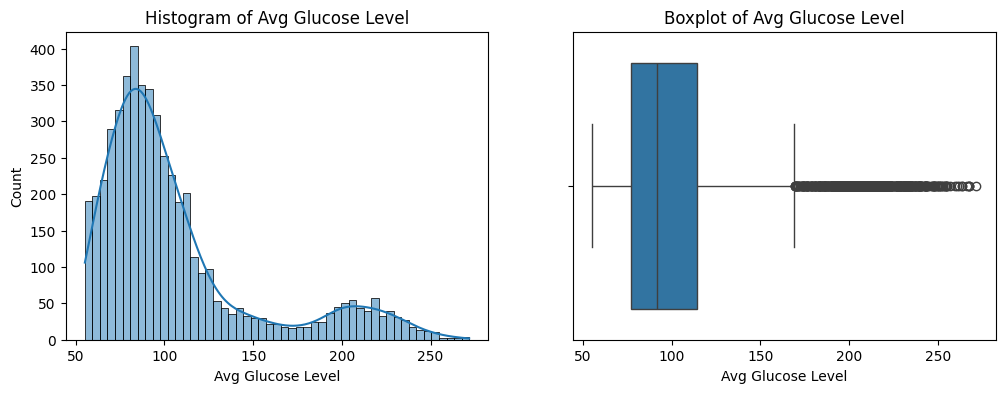

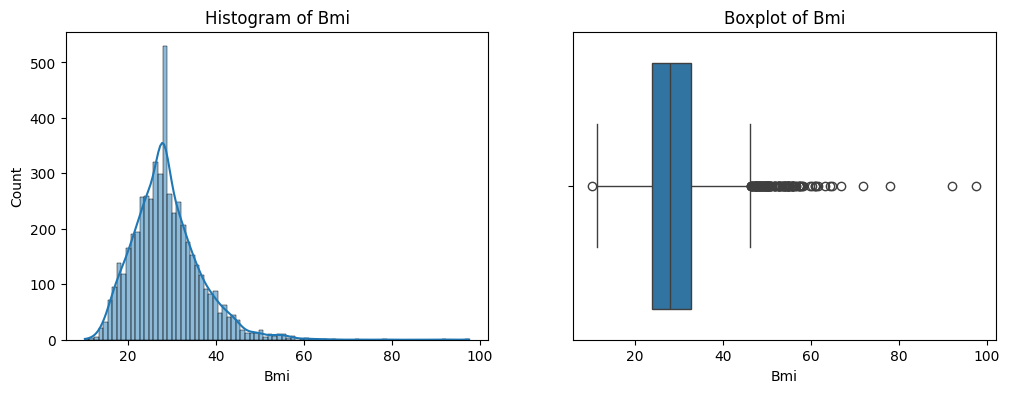

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(12,4))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df_begin[col], kde=True)
    plt.title(f"Histogram of {col}")


    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x = df_begin[col])
    plt.title(f"Boxplot of {col}")

    plt.show()

#### => The illustration shows that Avg Glucose Level's data and Bmi's data is heavily left-skewed.

### Visualize the binary features

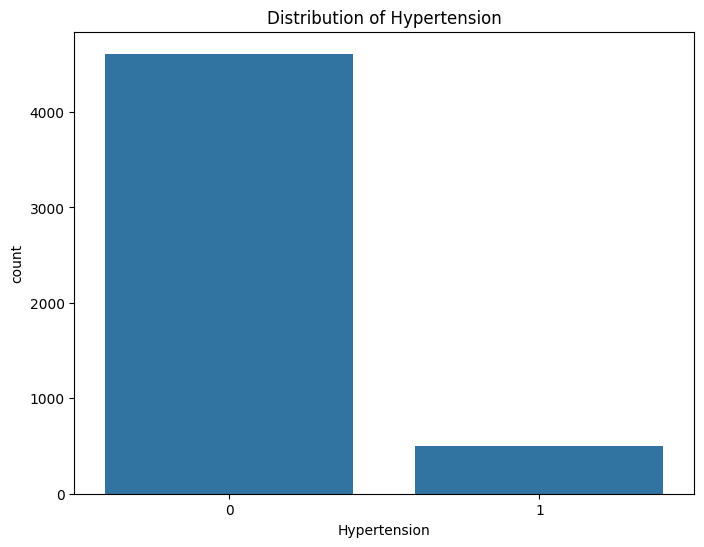

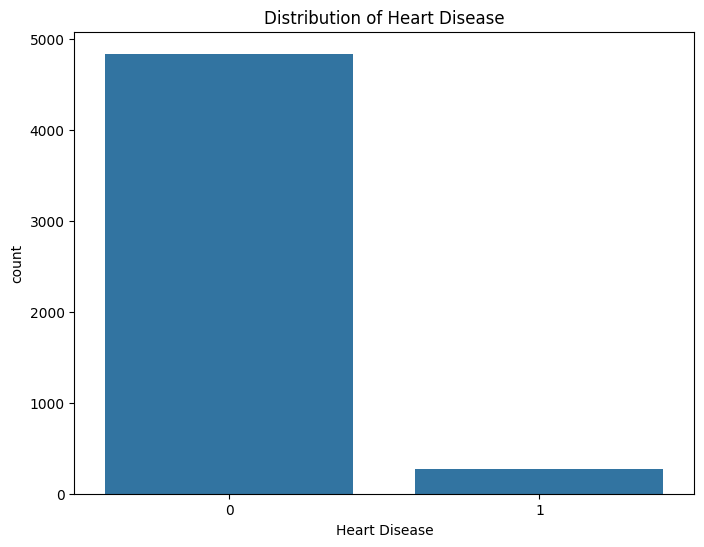

In [ ]:
for col in binary_cols:
    plt.figure(figsize=(8,6))

    sns.countplot(
        x = df_begin[col]
    )

    plt.title(f"Distribution of {col}")
    plt.show()

## V. Bivariate Analysis

### 1. Correlation matrix of numerical data and binary data with Stroke rate

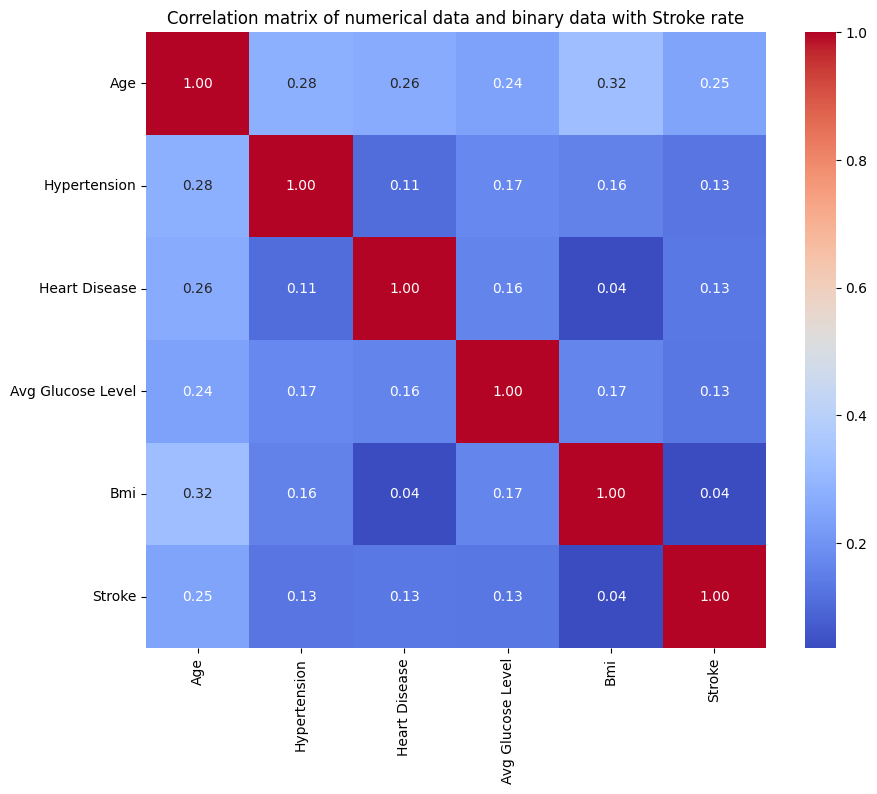

In [ ]:
plt.figure(figsize=(10, 8))
corr_cols = ['Age', 'Hypertension', 'Heart Disease', 'Avg Glucose Level', 'Bmi', 'Stroke']
corr_cols = [c for c in corr_cols if c in df_begin.columns]
corr_matrix = df_begin[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix of numerical data and binary data with Stroke rate')
plt.show()

#### => From this corr picture, we have comments:
#### - Firstly, Age shows the strongest positive correlation with Stroke among the numerical and binary features, with a correlation coefficient of approximately 0.25. Avg Glucose Level, Hypertension, and Heart Disease show weaker positive correlations with Stroke.
#### - Secondly, Age shows a weak correlation with all the remaining variables.
#### - Lastly, Bmi shows the weakest correnlation with Stroke rate but it has correlation with Age, Hypertension and Avg Glucose Level

### 2. Bmi, Avg Glucose Level with Stroke rate (check outilier)

In [ ]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: lower = {lower:.2f}, upper = {upper:.2f}, The number of outlier = {len(outliers)}")
    return outliers

out_glucose = detect_outliers_iqr(df_begin, 'Avg Glucose Level')
out_bmi = detect_outliers_iqr(df_begin, 'Bmi')

Avg Glucose Level: lower = 21.96, upper = 169.37, The number of outlier = 627
Bmi: lower = 10.30, upper = 46.30, The number of outlier = 126


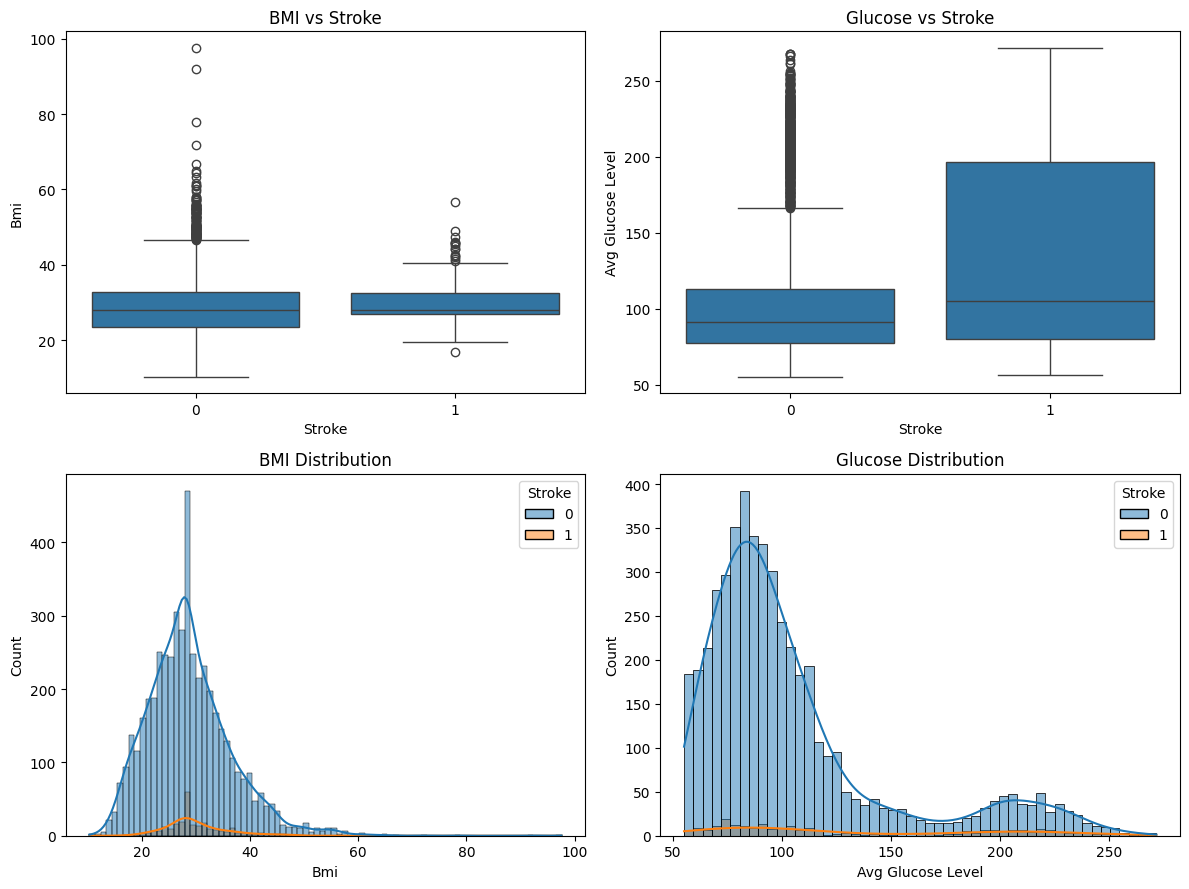

In [ ]:
# Visualize the distribution of BMI, Avg Glucose Level
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(
    data = df_begin,
    x = "Stroke",
    y = "Bmi",
    ax=axes[0, 0]
)
axes[0, 0].set_title("BMI vs Stroke")

sns.boxplot(
    data = df_begin,
    x = "Stroke",
    y = "Avg Glucose Level",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Glucose vs Stroke")

sns.histplot(
    data = df_begin,
    x = "Bmi",
    hue = "Stroke",
    kde = True,
    ax = axes[1, 0]
)
axes[1, 0].set_title("BMI Distribution")

sns.histplot(
    data = df_begin,
    x = "Avg Glucose Level",
    hue = "Stroke",
    kde = True,
    ax = axes[1, 1]
)
axes[1, 1].set_title("Glucose Distribution")

plt.tight_layout()
plt.show()

In [ ]:
print("Average stroke rate of outlier glucose group:", out_glucose['Stroke'].mean())
print("Average stroke rate of dataset:", df_begin['Stroke'].mean())

print("Average stroke rate of outlier bmi group:", out_bmi['Stroke'].mean())

Average stroke rate of outlier glucose group: 0.1339712918660287
Average stroke rate of dataset: 0.04873752201996477
Average stroke rate of outlier bmi group: 0.023809523809523808


#### => From the evidence and firgues, some excessively high BMI values ​​(>60) have little to no clinical relevance and are most likely due to data entry errors. Unlike BMI, abnormally high glucose levels (>200) are not data entry errors but reflect the presence of diabetes—a group with a stroke rate significantly higher than average.

### 3. Age with numerical data, Binary data and Stroke rate

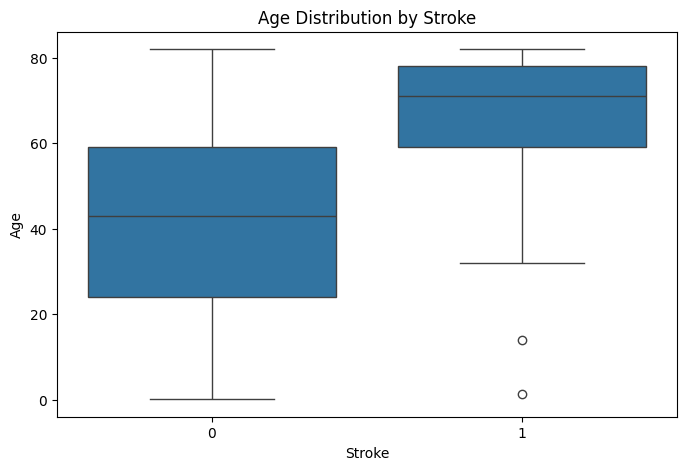

In [ ]:
# Age with Stroke
plt.figure(figsize=(8, 5))

sns.boxplot(
    data = df_begin,
    x = "Stroke",
    y = "Age"
)

plt.title("Age Distribution by Stroke")
plt.xlabel("Stroke")
plt.ylabel("Age")

plt.show()

#### => This firgue shows two cases of stroke in the 0–20 age group. In reality, it is not a data error; there are indeed cases of stroke occurring at a young age.

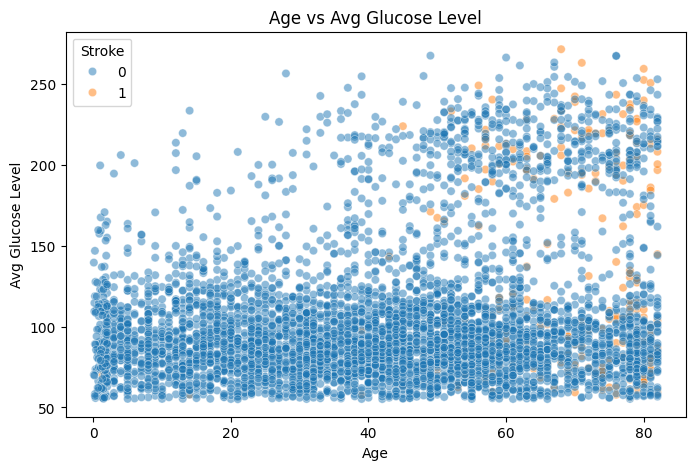

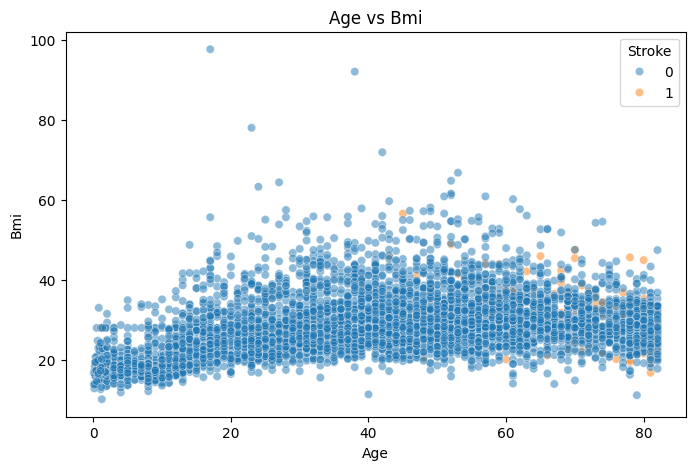

In [ ]:
# Age with numerical feature -> Stroke rate
numerical_features = ['Avg Glucose Level', 'Bmi']

for feature in numerical_features:

    # Scatter plot
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data = df_begin,
        x = "Age",
        y = feature,
        hue = "Stroke",
        alpha=0.5
    )

    plt.title(f"Age vs {feature}")
    plt.xlabel("Age")
    plt.ylabel(feature)

    plt.show()

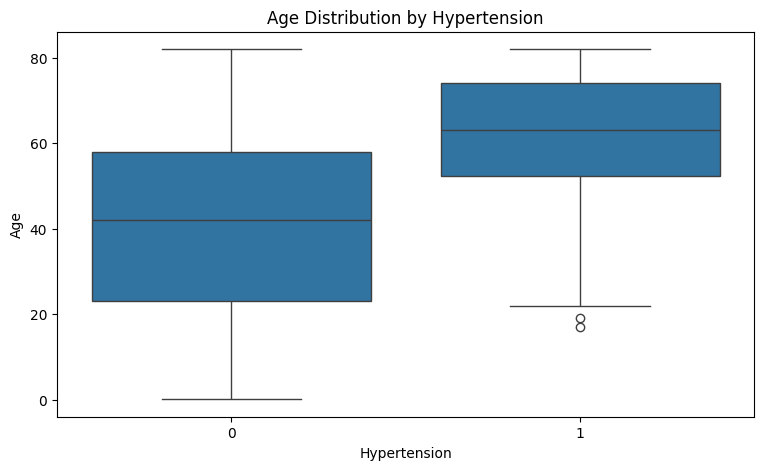

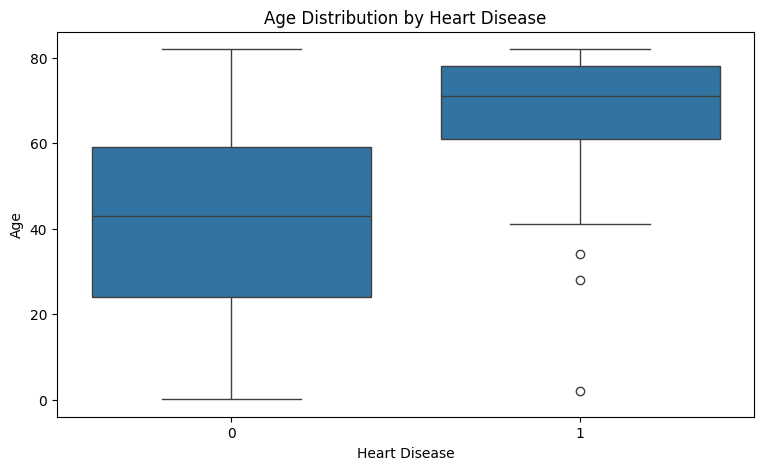

In [ ]:
# Age with Binary_features
Binary_features = ["Hypertension", "Heart Disease"]
for feature in Binary_features:

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data = df_begin,
        x = feature,
        y = "Age"
    )

    plt.title(f"Age Distribution by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Age")

    plt.show()

## 4. Hypertension and Heart Disease with Stroke

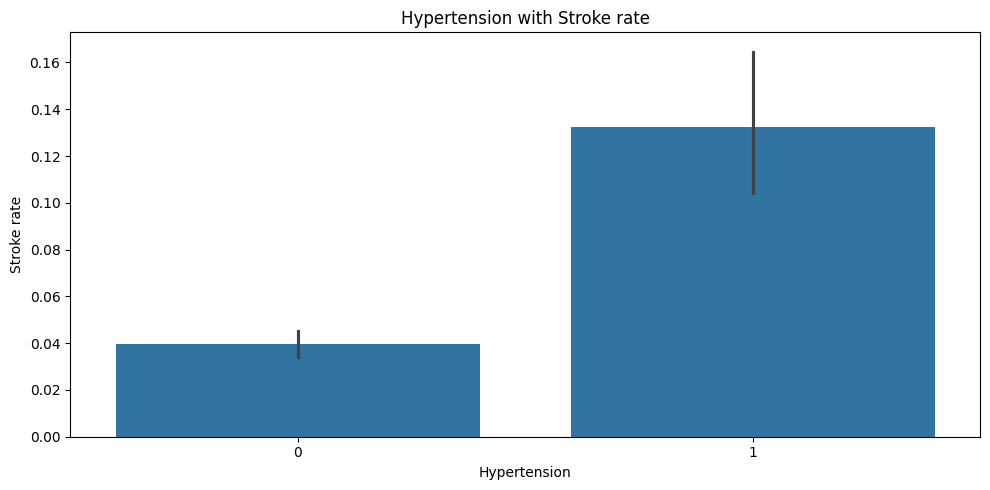

In [ ]:
# Check value
df_begin['Hypertension'].value_counts()

#Visualize with plot
plt.figure(figsize=(10,5))

sns.barplot(
  data = df_begin,
  x = "Hypertension",
  y = "Stroke"
)

plt.title("Hypertension with Stroke rate")
plt.xlabel("Hypertension")
plt.ylabel("Stroke rate")

plt.tight_layout()
plt.show()

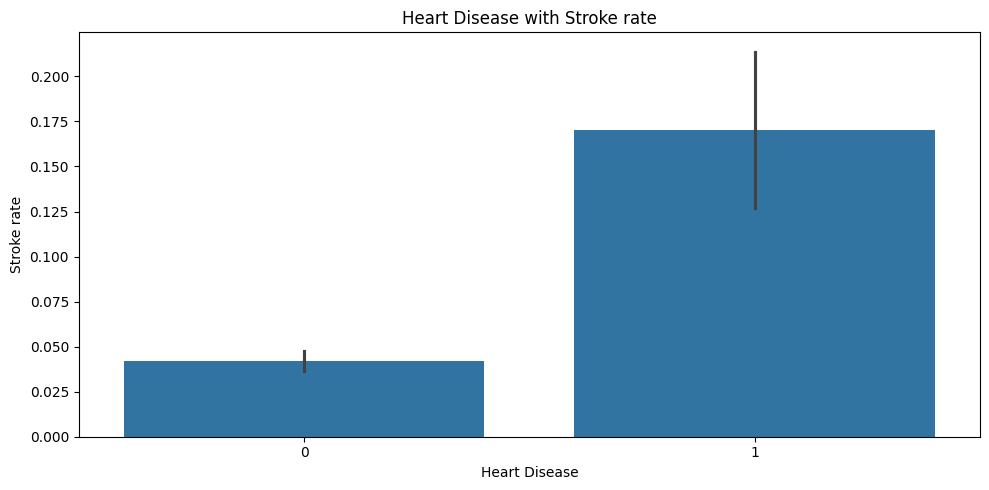

In [ ]:
df_begin['Heart Disease'].value_counts()

#Visualize with plot
plt.figure(figsize=(10,5))

sns.barplot(
  data = df_begin,
  x = "Heart Disease",
  y = "Stroke"
)

plt.title("Heart Disease with Stroke rate")
plt.xlabel("Heart Disease")
plt.ylabel("Stroke rate")

plt.tight_layout()
plt.show()

## 5. The categorical data with stroke rate


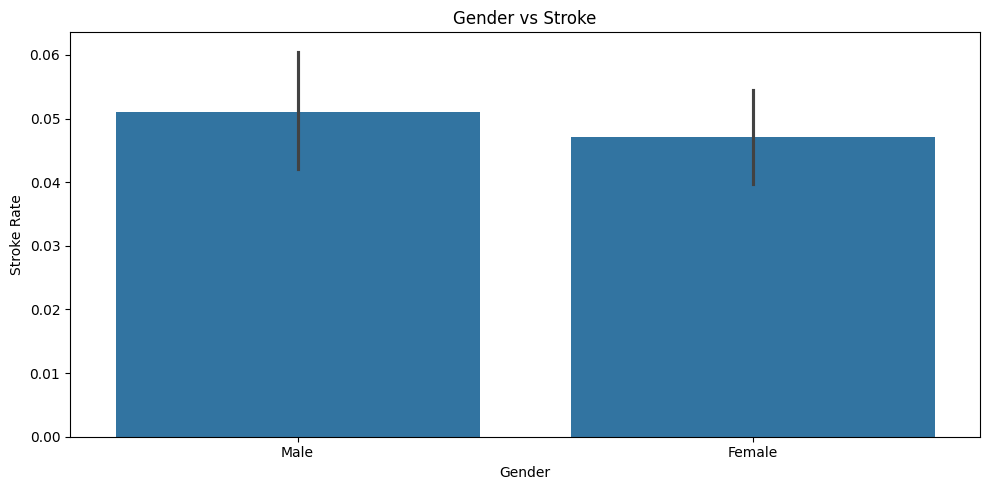

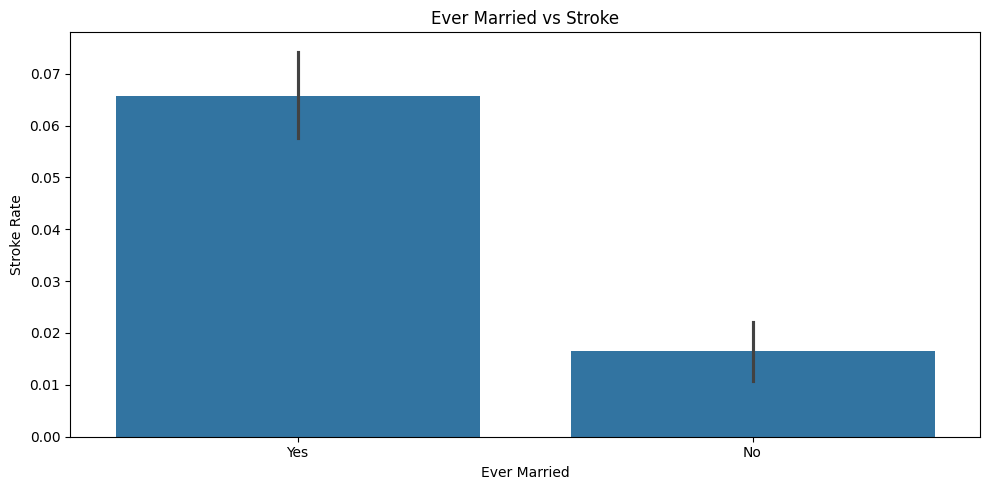

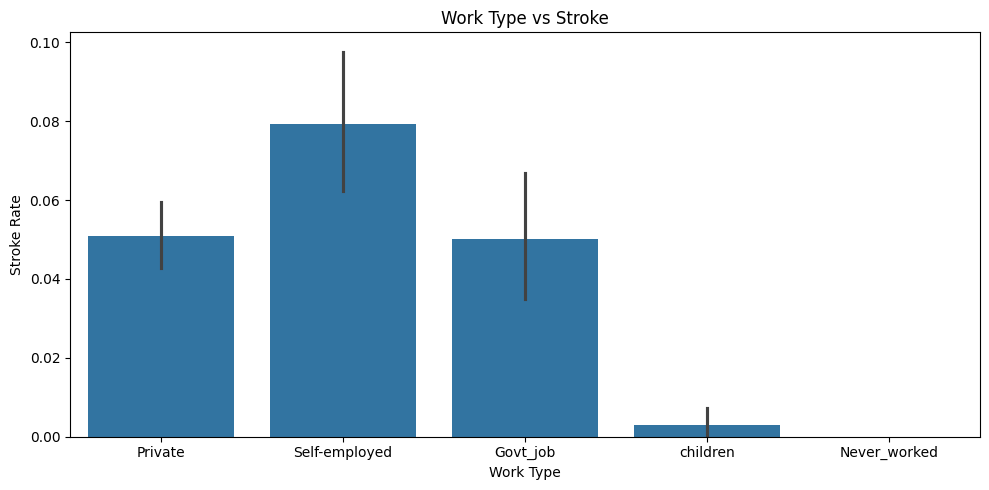

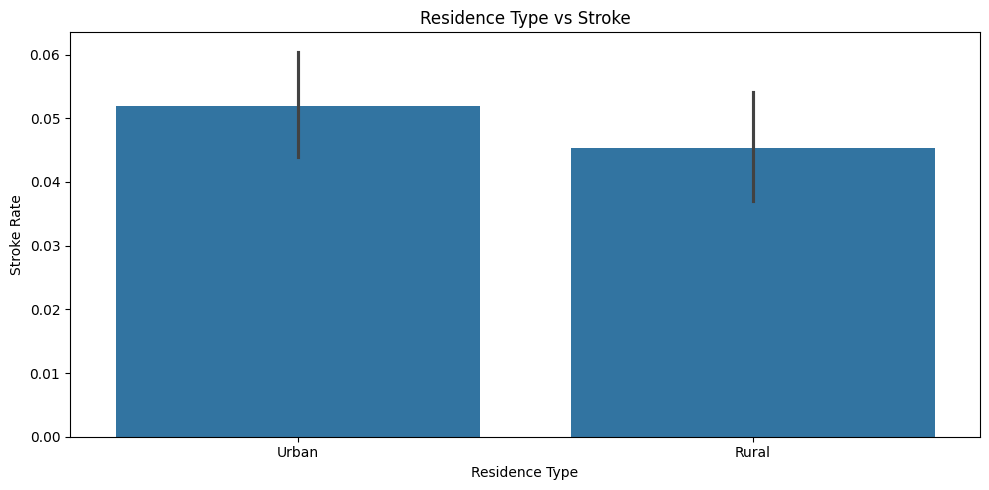

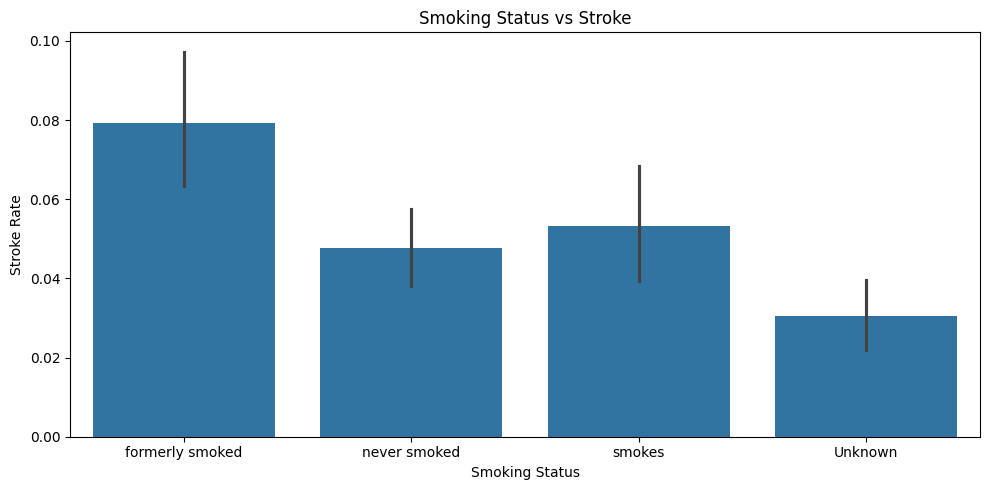

In [ ]:
categorical_features = [
    'Gender', 'Ever Married', 'Work Type', 'Residence Type', 'Smoking Status'
]

for feature in categorical_features:

    plt.figure(figsize=(10, 5))

    sns.barplot(
        data = df_begin,
        x = feature,
        y = "Stroke"
    )

    plt.title(f"{feature} vs Stroke")
    plt.xlabel(feature)
    plt.ylabel("Stroke Rate")


    plt.tight_layout()
    plt.show()

## VI. Data cleaning and feature engineering

### 1. Create a new dataframe from df_begin

In [42]:
df_clean = df_begin.copy()
df_clean.shape

(5109, 11)

### 2. Handling outilier and unsual values
Instead of completely removing these BMI outliers—which would mean losing the already rare cases where Stroke = 1 (approximately 4.9%)—we will **cap (Winsorize)** the BMI values ​​at a reasonable threshold based on the IQR.


Bmi bounds theo IQR: [10.30, 46.30]
Số điểm dữ liệu sẽ bị capping: 126


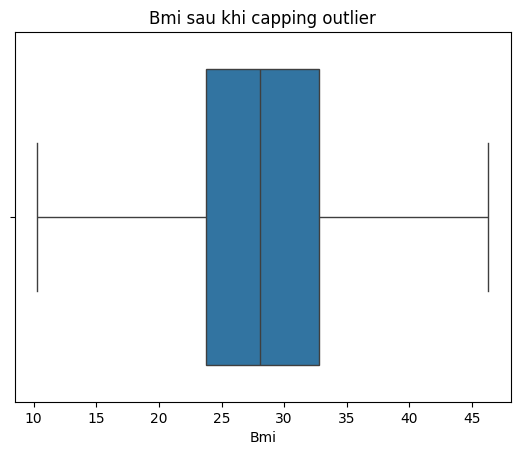

In [43]:
Q1 = df_clean['Bmi'].quantile(0.25)
Q3 = df_clean['Bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bmi = Q1 - 1.5 * IQR
upper_bmi = Q3 + 1.5 * IQR
print(f"Bmi bounds theo IQR: [{lower_bmi:.2f}, {upper_bmi:.2f}]")

n_capped = ((df_clean['Bmi'] < lower_bmi) | (df_clean['Bmi'] > upper_bmi)).sum()
print(f"Số điểm dữ liệu sẽ bị capping: {n_capped}")

# Bmi thực tế không nên thấp hơn ~10, giữ lower bound an toàn thay vì theo đúng IQR (có thể âm hoặc quá thấp)
df_clean['Bmi'] = df_clean['Bmi'].clip(lower=max(lower_bmi, 10), upper=upper_bmi)

sns.boxplot(x=df_clean['Bmi'])
plt.title('Bmi sau khi capping outlier')
plt.show()

#### With the outilier of Avg Glucose Level, we won't removing or capping Glucose. Instead of, we will use it to create new usefull feature

### 3. Feature engineering

### 3.1. Age_Group

In [ ]:
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 40:
        return 'Young Adult'
    elif age < 60:
        return 'Middle Aged'
    else:
        return 'Senior'

df_clean['Age Group'] = df_clean['Age'].apply(age_group)
df_clean['Age Group'].value_counts()

,count
Age Group,
Middle Aged,1564
Senior,1376
Young Adult,1313
Child,856


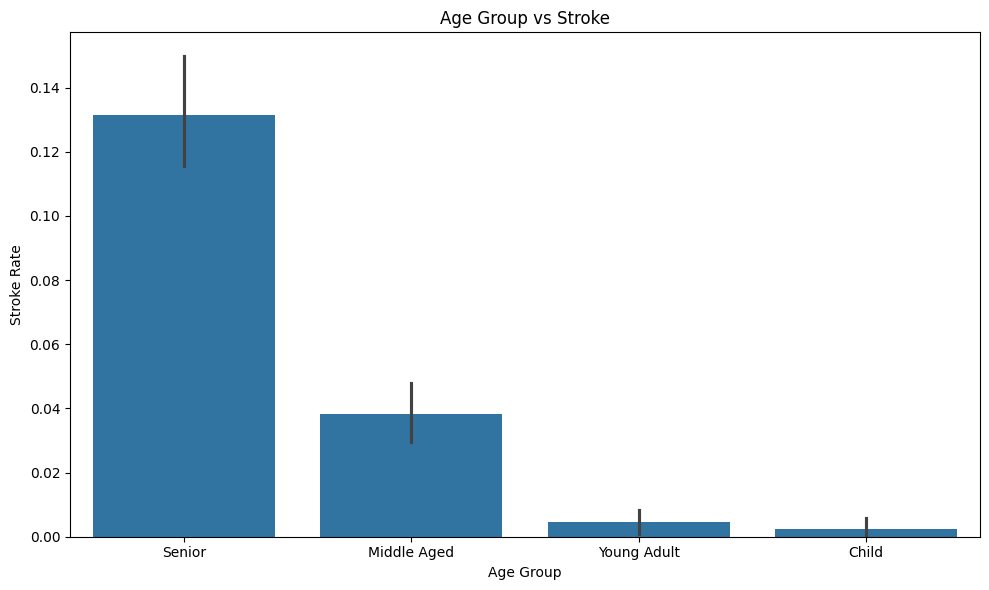

In [ ]:
# Visualize with plot
plt.figure(figsize=(10,6))
sns.barplot( data = df_clean, x = "Age Group", y = "Stroke")

plt.title("Age Group vs Stroke")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate")

plt.tight_layout()
plt.show()

### 3.2 Bmi Category (according to the standard WHO classification)

In [ ]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_clean['Bmi Category'] = df_clean['Bmi'].apply(bmi_category)
df_clean['Bmi Category'].value_counts()

,count
Bmi Category,
Obese,1920
Overweight,1610
Normal,1242
Underweight,337


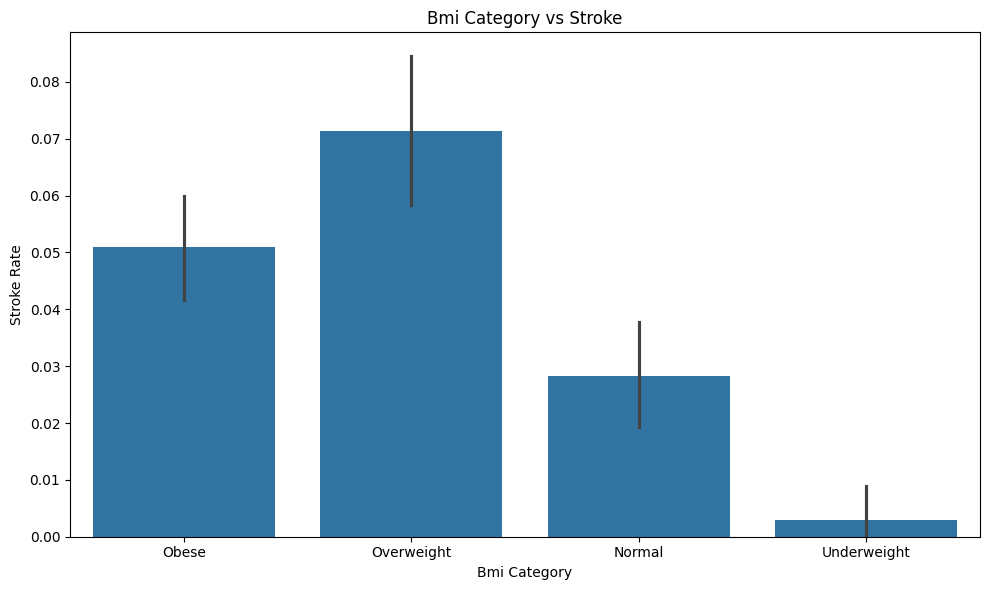

In [ ]:
# Visualize with plot
plt.figure(figsize=(10,6))
sns.barplot( data = df_clean, x = "Bmi Category", y = "Stroke")

plt.title("Bmi Category vs Stroke")
plt.xlabel("Bmi Category")
plt.ylabel("Stroke Rate")

plt.tight_layout()
plt.show()

### 3.3 Glucose Category (According to ADA - American Diabetes Association)

In [ ]:
def glucose_category(glucose):
    if glucose < 100:
        return 'Normal'
    elif glucose < 126:
        return 'Prediabetes'
    else:
        return 'Diabetes'

df_clean['Glucose Category'] = df_clean['Avg Glucose Level'].apply(glucose_category)
df_clean['Glucose Category'].value_counts()

,count
Glucose Category,
Normal,3131
Prediabetes,998
Diabetes,980


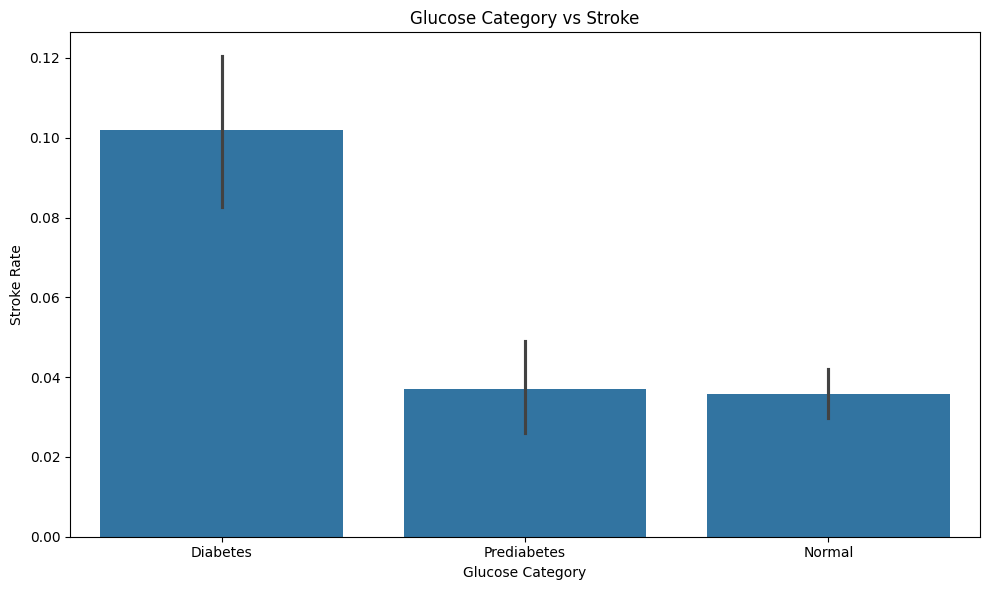

In [ ]:
# Visualize with plot
plt.figure(figsize=(10,6))
sns.barplot( data = df_clean, x = "Glucose Category", y = "Stroke")

plt.title("Glucose Category vs Stroke")
plt.xlabel("Glucose Category")
plt.ylabel("Stroke Rate")

plt.tight_layout()
plt.show()

### 3.4 "Comorbidity score" — number of underlying conditions
Group "Hypertension" and "Heart disease" into a single score (0, 1, or 2)

In [ ]:
df_clean['Comorbidity Score'] = df_clean['Hypertension'] + df_clean['Heart Disease']
df_clean['Comorbidity Score'].value_counts()

,count
Comorbidity Score,
0,4399
1,646
2,64


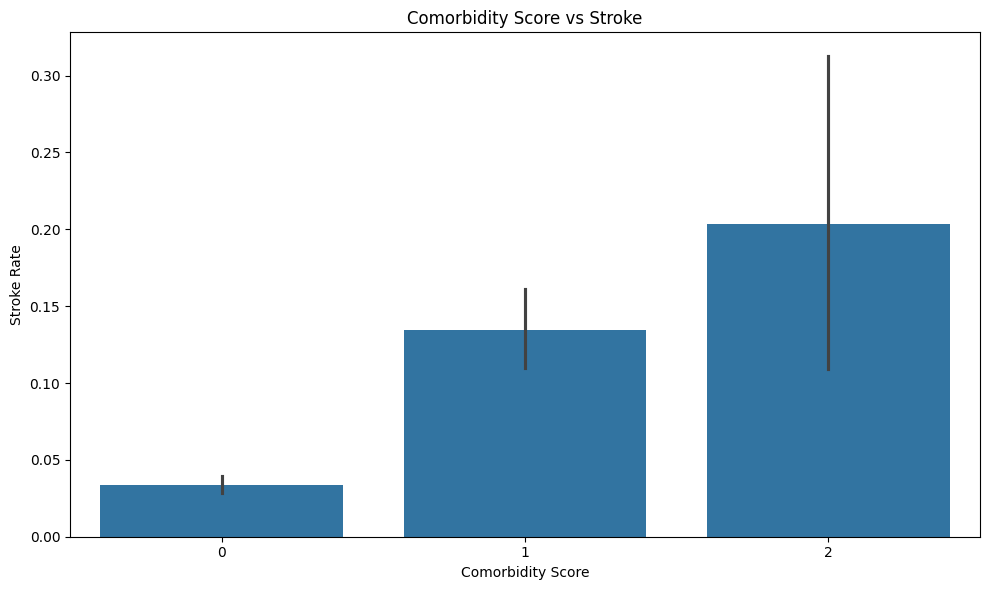

In [ ]:
# Visualize with plot
plt.figure(figsize=(10,6))
sns.barplot( data = df_clean, x = "Comorbidity Score", y = "Stroke")

plt.title("Comorbidity Score vs Stroke")
plt.xlabel("Comorbidity Score")
plt.ylabel("Stroke Rate")

plt.tight_layout()
plt.show()

### 3.5 `Is Smoker` — derived from `Smoking Status`
Combines 'smokes' and 'formerly smoked' into a smoking group (1), and 'never smoked' and 'Unknown' into the other group (0). This binary feature complements the original `Smoking Status` (the original `Smoking Status` is retained because 'Unknown' carries its own meaningful information—it is not equated with 'never smoked').

In [ ]:
df_clean['Is Smoker'] = df_clean['Smoking Status'].apply(
    lambda x: 1 if x in ['smokes', 'formerly smoked'] else 0
)
df_clean[['Smoking Status', 'Is Smoker']].drop_duplicates().sort_values('Smoking Status')

,Smoking Status,Is Smoker
8,Unknown,0
0,formerly smoked,1
1,never smoked,0
3,smokes,1


### 3.6 Interaction features: `Age × Bmi` and `Age × Glucose`
Strokes occur most frequently in older age groups **combined** with high BMI or glucose levels; creating these two interaction features allows the model—particularly Logistic Regression, which cannot automatically learn non-linear interactions—to capture this information.

In [ ]:
df_clean['Age Bmi Interaction'] = df_clean['Age'] * df_clean['Bmi']
df_clean['Age Glucose Interaction'] = df_clean['Age'] * df_clean['Avg Glucose Level']
df_clean[['Age Bmi Interaction', 'Age Glucose Interaction']].describe()

,Age Bmi Interaction,Age Glucose Interaction
count,5109.000000,5109.000000
mean,1296.852157,4832.456135
std,751.030043,3883.925993
min,1.128000,5.626400
25%,680.000000,2179.250000
50%,1332.800000,3960.000000
75%,1866.900000,6080.400000
max,3796.600000,20770.400000


#### => The higher the interaction index, the greater the susceptibility to the disease.

## 4. Statistical testing to eliminate unnecessary features
Use the **Chi-square test** for categorical or binned variables against `Stroke`. If the p-value > 0.05, the variable lacks a statistically significant relationship with `Stroke` in this dataset; consider removing it to reduce noise.

In [ ]:
from scipy.stats import chi2_contingency

cat_check_cols = ['Gender', 'Ever Married', 'Work Type', 'Residence Type',
                   'Smoking Status', 'Age Group', 'Bmi Category', 'Glucose Category']

p_values = {}
for col in cat_check_cols:
    contingency = pd.crosstab(df_clean[col], df_clean['Stroke'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    p_values[col] = p
    flag = '-> Meaningless (p > 0.05)' if p > 0.05 else '-> Meaningfull'
    print(f"{col:20s} -> chi2={chi2:8.2f}, p-value={p:.4f}  {flag}")

Gender               -> chi2=    0.34, p-value=0.5598  -> Meaningless (p > 0.05)
Ever Married         -> chi2=   58.87, p-value=0.0000  -> Meaningfull
Work Type            -> chi2=   49.16, p-value=0.0000  -> Meaningfull
Residence Type       -> chi2=    1.07, p-value=0.2998  -> Meaningless (p > 0.05)
Smoking Status       -> chi2=   29.23, p-value=0.0000  -> Meaningfull
Age Group            -> chi2=  302.12, p-value=0.0000  -> Meaningfull
Bmi Category         -> chi2=   44.65, p-value=0.0000  -> Meaningfull
Glucose Category     -> chi2=   74.34, p-value=0.0000  -> Meaningfull


**Observation:** The columns listed above with p-values ​​> 0.05 do not show a sufficiently strong association with `Stroke` to warrant retention. `Residence Type` typically falls into this category in the public Kaggle dataset (with an Urban/Rural split of nearly 50/50 across both stroke groups). We will drop these columns automatically based on the test results rather than hard-coding their names, ensuring the logic remains valid if the process is re-run with different data or a different train/test split.

In [ ]:
cols_to_drop = [col for col, p in p_values.items() if p > 0.05]
print('The columns will be removed (not statistically significant with Stroke):', cols_to_drop)

df_clean = df_clean.drop(columns=cols_to_drop)
df_clean.head()

The columns will be removed (not statistically significant with Stroke): ['Gender', 'Residence Type']


,Age,Hypertension,Heart Disease,Ever Married,Work Type,Avg Glucose Level,Bmi,Smoking Status,Stroke,Age Group,Bmi Category,Glucose Category,Comorbidity Score,Is Smoker,Age Bmi Interaction,Age Glucose Interaction
0,67.0,0,1,Yes,Private,228.69,36.6,formerly smoked,1,Senior,Obese,Diabetes,1,1,2452.2,15322.23
1,61.0,0,0,Yes,Self-employed,202.21,28.1,never smoked,1,Senior,Overweight,Diabetes,0,0,1714.1,12334.81
2,80.0,0,1,Yes,Private,105.92,32.5,never smoked,1,Senior,Obese,Prediabetes,1,0,2600.0,8473.60
3,49.0,0,0,Yes,Private,171.23,34.4,smokes,1,Middle Aged,Obese,Diabetes,0,1,1685.6,8390.27
4,79.0,1,0,Yes,Self-employed,174.12,24.0,never smoked,1,Senior,Normal,Diabetes,1,0,1896.0,13755.48


## 5. Consolidate the final data and save it.

In [ ]:
print('All colums in cleaning dataset:')
print(df_clean.columns.tolist())
print('\nSize:', df_clean.shape)
print('The number of missing value:', df_clean.isna().sum().sum())
print('The number of duplicate value:', df_clean.duplicated().sum())
df_clean.head()

All colums in cleaning dataset:
['Age', 'Hypertension', 'Heart Disease', 'Ever Married', 'Work Type', 'Avg Glucose Level', 'Bmi', 'Smoking Status', 'Stroke', 'Age Group', 'Bmi Category', 'Glucose Category', 'Comorbidity Score', 'Is Smoker', 'Age Bmi Interaction', 'Age Glucose Interaction']

Size: (5109, 16)
The number of missing value: 0
The number of duplicate value: 0


,Age,Hypertension,Heart Disease,Ever Married,Work Type,Avg Glucose Level,Bmi,Smoking Status,Stroke,Age Group,Bmi Category,Glucose Category,Comorbidity Score,Is Smoker,Age Bmi Interaction,Age Glucose Interaction
0,67.0,0,1,Yes,Private,228.69,36.6,formerly smoked,1,Senior,Obese,Diabetes,1,1,2452.2,15322.23
1,61.0,0,0,Yes,Self-employed,202.21,28.1,never smoked,1,Senior,Overweight,Diabetes,0,0,1714.1,12334.81
2,80.0,0,1,Yes,Private,105.92,32.5,never smoked,1,Senior,Obese,Prediabetes,1,0,2600.0,8473.60
3,49.0,0,0,Yes,Private,171.23,34.4,smokes,1,Middle Aged,Obese,Diabetes,0,1,1685.6,8390.27
4,79.0,1,0,Yes,Self-employed,174.12,24.0,never smoked,1,Senior,Normal,Diabetes,1,0,1896.0,13755.48


In [ ]:
# Save the last dataset
df_clean.to_csv('Output/stroke_data_clean.csv', index=False)
print("SAVE FINISH")

SAVE FINISH


In [4]:
# Read and take data clean 
df_clean = pd.read_csv('Output/stroke_data_clean.csv')
df_clean.head()

,Age,Hypertension,Heart Disease,Ever Married,Work Type,Avg Glucose Level,Bmi,Smoking Status,Stroke,Age Group,Bmi Category,Glucose Category,Comorbidity Score,Is Smoker,Age Bmi Interaction,Age Glucose Interaction
0,67.0,0,1,Yes,Private,228.69,36.6,formerly smoked,1,Senior,Obese,Diabetes,1,1,2452.2,15322.23
1,61.0,0,0,Yes,Self-employed,202.21,28.1,never smoked,1,Senior,Overweight,Diabetes,0,0,1714.1,12334.81
2,80.0,0,1,Yes,Private,105.92,32.5,never smoked,1,Senior,Obese,Prediabetes,1,0,2600.0,8473.60
3,49.0,0,0,Yes,Private,171.23,34.4,smokes,1,Middle Aged,Obese,Diabetes,0,1,1685.6,8390.27
4,79.0,1,0,Yes,Self-employed,174.12,24.0,never smoked,1,Senior,Normal,Diabetes,1,0,1896.0,13755.48


# DATA STANDARDIZATION AND TRAINING MODEL

In [ ]:
df_clean.columns

Index(['Age', 'Hypertension', 'Heart Disease', 'Ever Married', 'Work Type',
       'Avg Glucose Level', 'Bmi', 'Smoking Status', 'Stroke', 'Age Group',
       'Bmi Category', 'Glucose Category', 'Comorbidity Score', 'Is Smoker',
       'Age Bmi Interaction', 'Age Glucose Interaction'],
      dtype='object')

In [5]:
# import processors
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline

In [6]:
# import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay, f1_score

In [ ]:
# import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [15]:
# Prepare the value for training model
X = df_clean.drop(['Stroke'], axis = 1)
y = df_clean['Stroke']

# Split the value
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [12]:
# Feature classification
numerical_features = ['Age', 'Avg Glucose Level', 'Bmi', 'Comorbidity Score', 'Age Bmi Interaction', 'Age Glucose Interaction']
categorical_features = ['Ever Married', 'Work Type', 'Smoking Status', 'Age Group', 'Bmi Category', 'Glucose Category']
Binary_features = ['Hypertension', 'Heart Disease', 'Is Smoker']

In [13]:
# Prepare processor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', Binary_features),
    ],
    remainder='drop'
)

## 1. Use Cross - Validation to train and tun hyperparameter

In [16]:
# Cross - Validation with StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# class: balanced replace by scale_pos_weight for XGBoost and LightGBM
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [17]:
# Prepare model's pipeline

models = {
    "Logistic Regression":
    Pipeline([
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter = 2000, class_weight = "balanced", random_state = 42))
    ]),

    "Random Forest":
    Pipeline([
        ("prep", preprocessor),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
    ]),

    "XGBoost":
    Pipeline([
        ("prep", preprocessor),
        ("clf", XGBClassifier(
            scale_pos_weight = scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            gamma = 1,
            random_state=42,
            n_jobs=-1 ))
    ]),

    "LightGBM":
    Pipeline([
        ("prep", preprocessor),
        ("clf", LGBMClassifier(
            scale_pos_weight = scale_pos_weight,
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbose =-1,
            max_depth = -1))
    ])
}

In [17]:
# Prepare the set of hyperparameters for each model
param_grids = {

    "Logistic Regression": {
        "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "clf__solver": ["liblinear", "lbfgs"],
    },


    "Random Forest": {
        "clf__n_estimators": [200, 300],
        "clf__max_depth": [5, 10, 15],
        "clf__min_samples_leaf": [5, 10, 20],
        "clf__max_features": ["sqrt", "log2"],
    },

    "XGBoost": {
        "clf__n_estimators": [300, 400, 500],
        "clf__learning_rate": [0.01, 0.03, 0.1, 0.2],
        "clf__max_depth": [4, 5, 6, 8],
        "clf__min_child_weight": [5, 10],
        "clf__subsample": [0.8, 0.9],
        "clf__colsample_bytree": [0.8, 0.9],
    },

    "LightGBM": {
        "clf__n_estimators": [300, 400, 500],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "clf__num_leaves": [31, 50, 70],
        "clf__min_child_samples": [10, 20, 30, 50],
        "clf__subsample": [0.8, 0.9],
        "clf__colsample_bytree": [0.8, 0.9],
    }
}

In [18]:
# Tuning and compare
scoring = {
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

search_results = {}
results_summary = {}

for name in models:

    print("=" * 60)
    print(f"Tuning: {name}")

    search = GridSearchCV(
        estimator = models[name],
        param_grid = param_grids[name],
        scoring = scoring,
        cv = skf,
        n_jobs = -1,
        refit = 'pr_auc'
    )

    search.fit(X_train, y_train)

    search_results[name] = search

    best_idx = search.best_index_
    cvres = search.cv_results_
    results_summary[name] = {metric: cvres[f'mean_test_{metric}'][best_idx] for metric in scoring}

    print(f"Best parameters: {search.best_params_}")
    for metric in scoring:
        print(f"  {metric:10s}: {results_summary[name][metric]:.3f}")
    print()

cv_summary_df = pd.DataFrame(results_summary).T
cv_summary_df

Tuning: Logistic Regression
Best parameters: {'clf__C': 0.1, 'clf__solver': 'liblinear'}
  recall    : 0.844
  precision : 0.134
  f1        : 0.231
  roc_auc   : 0.840
  pr_auc    : 0.197

Tuning: Random Forest
Best parameters: {'clf__max_depth': 5, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 20, 'clf__n_estimators': 200}
  recall    : 0.819
  precision : 0.124
  f1        : 0.215
  roc_auc   : 0.834
  pr_auc    : 0.184

Tuning: XGBoost
Best parameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 4, 'clf__min_child_weight': 5, 'clf__n_estimators': 400, 'clf__subsample': 0.9}
  recall    : 0.744
  precision : 0.131
  f1        : 0.222
  roc_auc   : 0.832
  pr_auc    : 0.191

Tuning: LightGBM
Best parameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__min_child_samples': 50, 'clf__n_estimators': 500, 'clf__num_leaves': 50, 'clf__subsample': 0.8}
  recall    : 0.417
  precision : 0.178
  f1        : 0.249
  roc_auc   : 0.83

,recall,precision,f1,roc_auc,pr_auc
Logistic Regression,0.844359,0.133652,0.230759,0.840498,0.196843
Random Forest,0.818974,0.123656,0.214854,0.834427,0.184327
XGBoost,0.744103,0.130799,0.222478,0.832143,0.191030
LightGBM,0.417436,0.177763,0.248773,0.832634,0.181970


In [19]:
# Save model score
import joblib

# Save search_results và results_summary
joblib.dump(search_results, 'Output/search_results.pkl')
joblib.dump(results_summary, 'Output/results_summary.pkl')

# Save cv_summary_df
cv_summary_df.to_csv('Output/cv_summary_results.csv', index=True)

print("SAVE FINISH")

SAVE FINISH


In [8]:
import joblib

search_results = joblib.load('Output/search_results.pkl')
results_summary = joblib.load('Output/results_summary.pkl')

cv_summary_df = pd.read_csv('Output/cv_summary_results.csv', index_col=0)

print("LOAD FINISH")

LOAD FINISH


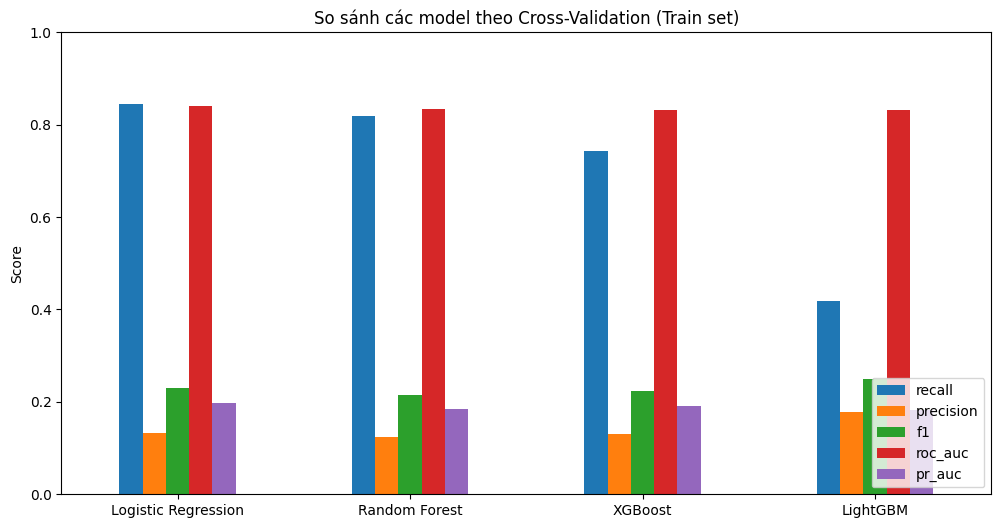

In [21]:
# Visualize the result with plot
cv_summary_df[['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']].plot(
    kind='bar', figsize=(12, 6)
)
plt.title('So sánh các model theo Cross-Validation (Train set)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.show()

## 2. Choose the best model according to pr-auc score

In [20]:
best_model_name = max(results_summary, key=lambda k: results_summary[k]['pr_auc'])
best_search = search_results[best_model_name]
best_pipeline = best_search.best_estimator_

print('Best model according to pr_auc score:', best_model_name)
print('Set of Hyperparameter:', best_search.best_params_)
print('CV scores:', results_summary[best_model_name])

Best model according to pr_auc score: Logistic Regression
Set of Hyperparameter: {'clf__C': 0.1, 'clf__solver': 'liblinear'}
CV scores: {'recall': np.float64(0.8443589743589743), 'precision': np.float64(0.13365214484229876), 'f1': np.float64(0.23075887051728855), 'roc_auc': np.float64(0.8404981970020531), 'pr_auc': np.float64(0.19684282417026241)}


## 3. Tuning threshold

In [21]:
# Tuning for best model according to pr-auc score
y_prob_oof = cross_val_predict(best_pipeline, X_train, y_train, cv=skf,
                                method='predict_proba', n_jobs=-1)[:, 1]

best_threshold = 0.5
best_score = 0.0

for threshold in np.arange(0.3, 0.8, 0.01):
    y_pred = (y_prob_oof >= threshold).astype(int)
    score = f1_score(y_train, y_pred)
    if score > best_score:
        best_score = score
        best_threshold = threshold

print (f'The best threshold: {best_threshold:.2f}')
print (f'The best average precision score: {best_score:.4f}')

The best threshold: 0.70
The best average precision score: 0.2571


In [18]:
# Tuning threshold for all models
best_thresholds = {}
for model in models:
  print(f'Searching best threshold for {model}:')
  model_search = search_results[model]
  model_pipeline = model_search.best_estimator_

  y_prob_oof = cross_val_predict(model_pipeline, X_train, y_train, cv=skf,
                                  method='predict_proba', n_jobs=-1)[:, 1]

  best_threshold = 0.5
  best_score = 0.0

  for threshold in np.arange(0.3, 0.8, 0.01):
      y_pred = (y_prob_oof >= threshold).astype(int)
      score = f1_score(y_train, y_pred)
      if score > best_score:
          best_score = score
          best_threshold = threshold

  best_thresholds[model] = {'best_threshold': best_threshold}

  print (f'The best threshold: {best_threshold:.2f}')
  print (f'The best F1 score: {best_score:.3f}')
  print('\n')

Searching best threshold for Logistic Regression:
The best threshold: 0.70
The best F1 score: 0.257


Searching best threshold for Random Forest:
The best threshold: 0.66
The best F1 score: 0.252


Searching best threshold for XGBoost:
The best threshold: 0.63
The best F1 score: 0.258


Searching best threshold for LightGBM:
The best threshold: 0.45
The best F1 score: 0.255




## 4. Train models with train and test set

In [22]:
# Train and evaluate the best model
best_pipeline.fit(X_train, y_train)
y_prob_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

print(f"Model: {best_model_name} | Hyperparameters: {best_search.best_params_} | Threshold = {best_threshold:.3f}")
print()
print(classification_report(y_test, y_pred_test))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_test):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_prob_test):.3f}")

Model: Logistic Regression | Hyperparameters: {'clf__C': 0.1, 'clf__solver': 'liblinear'} | Threshold = 0.700

              precision    recall  f1-score   support

           0       0.98      0.87      0.93       972
           1       0.22      0.70      0.34        50

    accuracy                           0.87      1022
   macro avg       0.60      0.79      0.63      1022
weighted avg       0.95      0.87      0.90      1022

ROC-AUC: 0.845
PR-AUC:  0.261


In [23]:
# Train và evaluate all models
for model in models:
  print(f'Training {model}:')
  model_search = search_results[model]
  model_pipeline = model_search.best_estimator_
  best_threshold = best_thresholds[model]['best_threshold']
  model_pipeline.fit(X_train, y_train)
  y_prob_test = model_pipeline.predict_proba(X_test)[:, 1]
  y_pred_test = (y_prob_test >= best_threshold).astype(int)

  print(f'Evaluation report of {model} after training:')
  print(f"Model: {model} | Hyperparameters: {model_search.best_params_} | Threshold = {best_threshold:.3f}")
  print()
  print(classification_report(y_test, y_pred_test))
  print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_test):.3f}")
  print(f"PR-AUC:  {average_precision_score(y_test, y_prob_test):.3f} \n")

Training Logistic Regression:
Evaluation report of Logistic Regression after training:
Model: Logistic Regression | Hyperparameters: {'clf__C': 0.1, 'clf__solver': 'liblinear'} | Threshold = 0.700

              precision    recall  f1-score   support

           0       0.98      0.87      0.93       972
           1       0.22      0.70      0.34        50

    accuracy                           0.87      1022
   macro avg       0.60      0.79      0.63      1022
weighted avg       0.95      0.87      0.90      1022

ROC-AUC: 0.845
PR-AUC:  0.261 

Training Random Forest:
Evaluation report of Random Forest after training:
Model: Random Forest | Hyperparameters: {'clf__max_depth': 5, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 20, 'clf__n_estimators': 200} | Threshold = 0.660

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       972
           1       0.21      0.74      0.33        50

    accuracy                         

ROC curve; PR-AUC curve and confusion matrix of Logistic Regression:


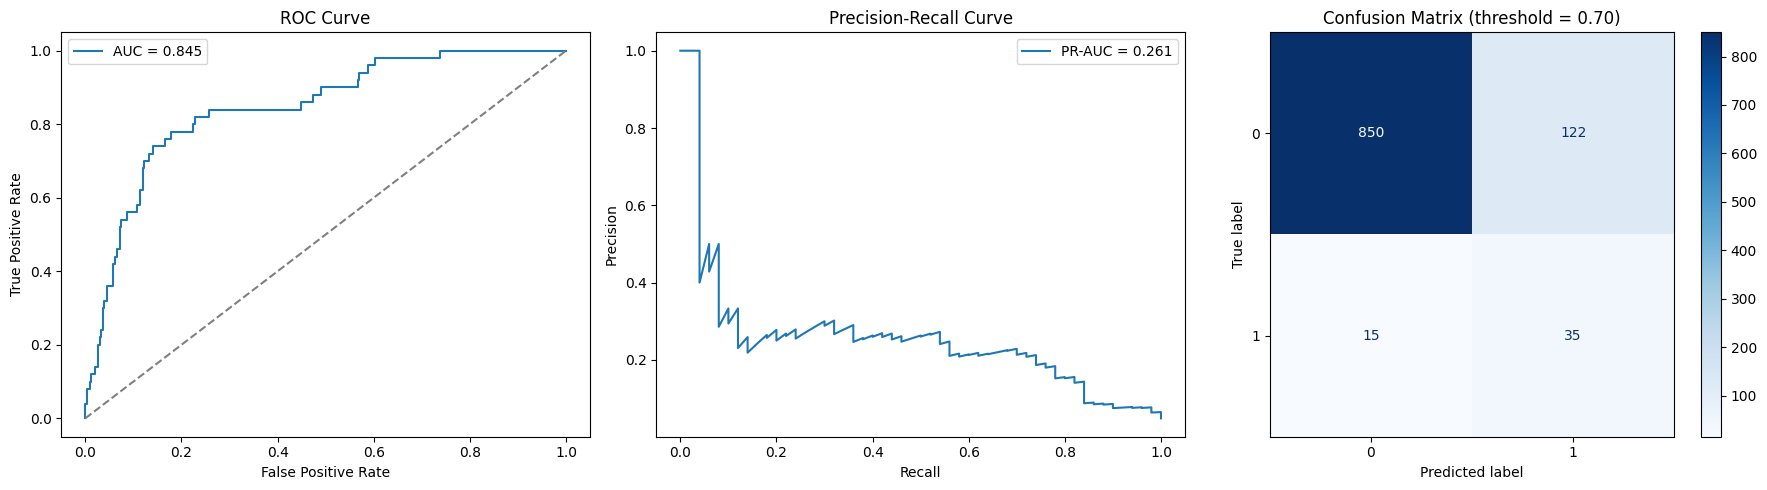

ROC curve; PR-AUC curve and confusion matrix of Random Forest:


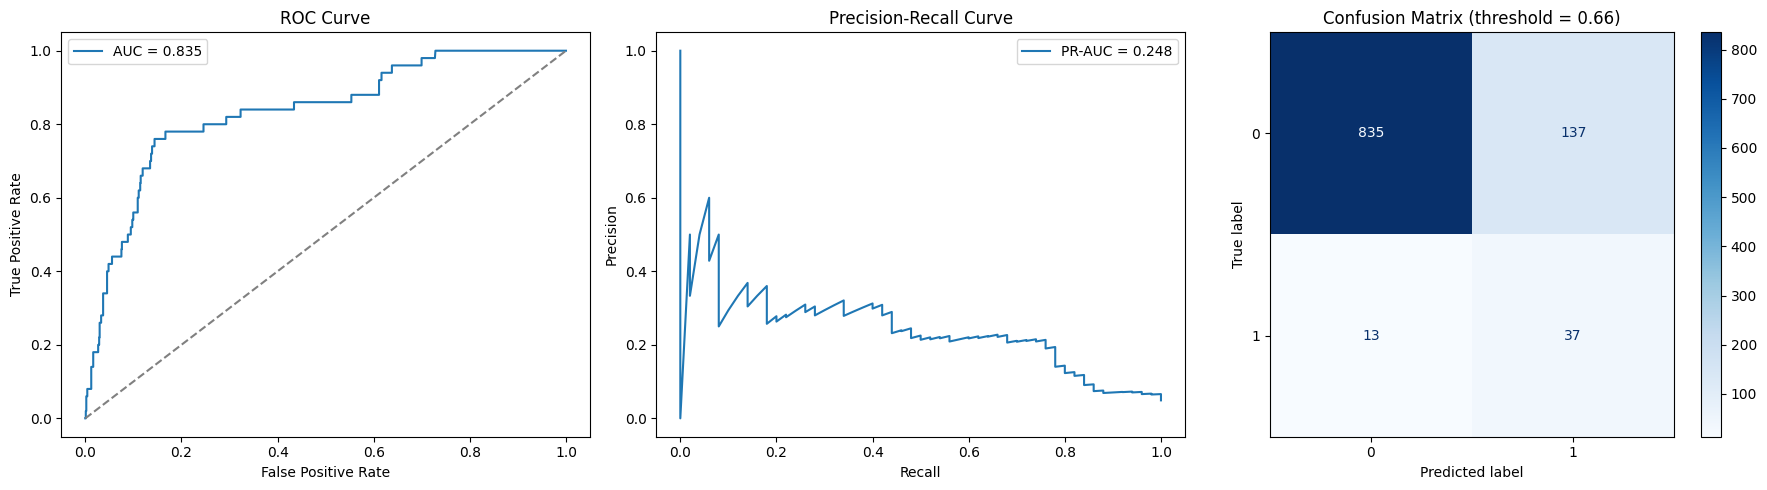

ROC curve; PR-AUC curve and confusion matrix of XGBoost:


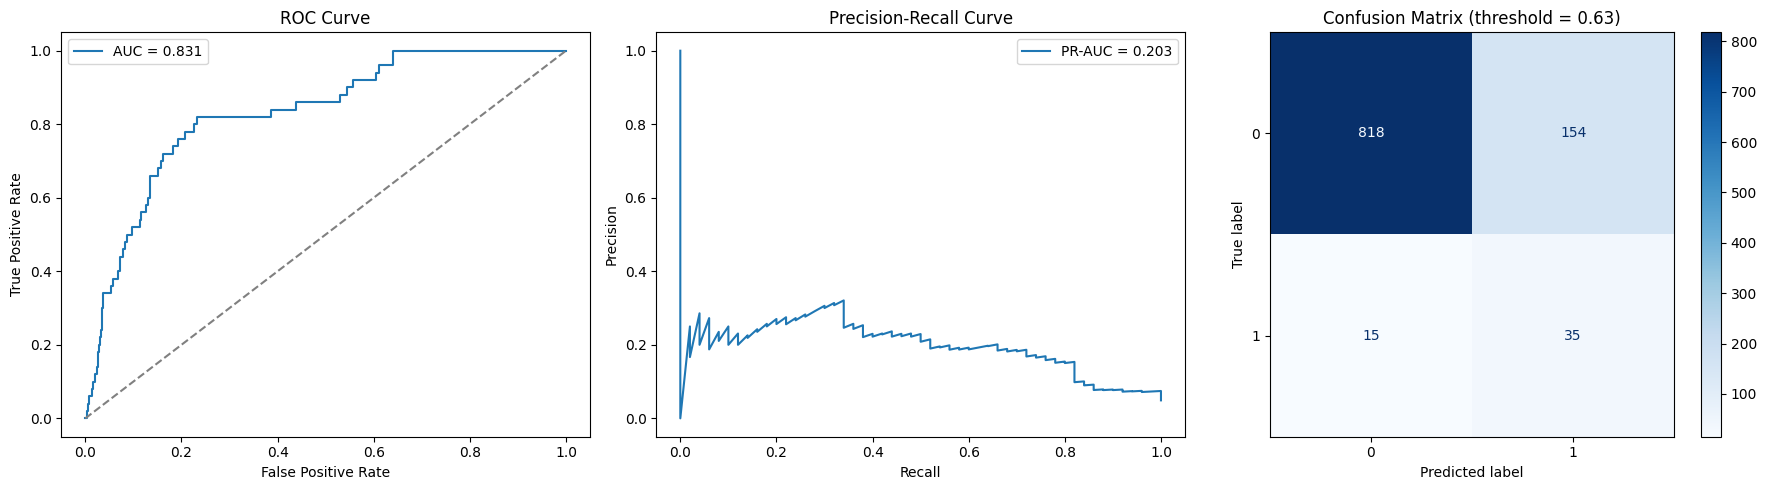

ROC curve; PR-AUC curve and confusion matrix of LightGBM:


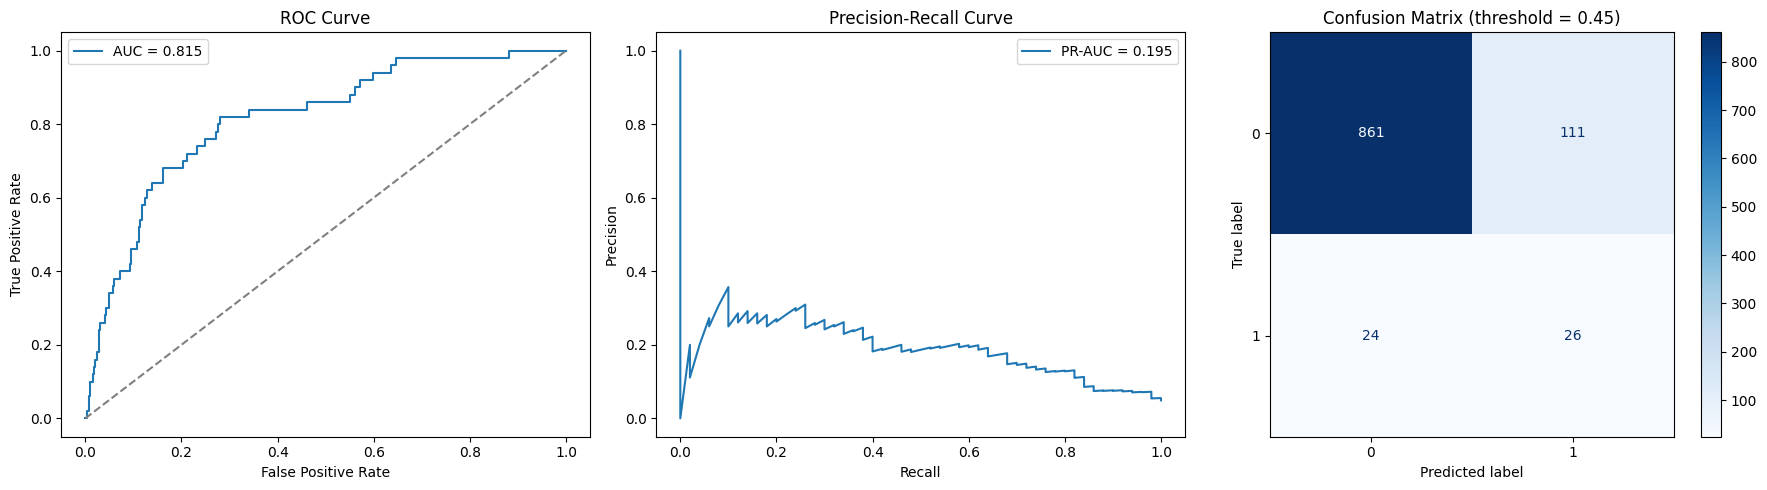

In [ ]:
# ROC curve, PR curve and confusion matrix 
for model in models:
  print(f'ROC curve; PR-AUC curve and confusion matrix of {model}:')
  model_search = search_results[model]
  model_pipeline = model_search.best_estimator_
  best_threshold = best_thresholds[model]['best_threshold']
  model_pipeline.fit(X_train, y_train)
  y_prob_test = model_pipeline.predict_proba(X_test)[:, 1]
  y_pred_test = (y_prob_test >= best_threshold).astype(int)

  fig, axes = plt.subplots(1, 3, figsize=(18, 5))

  # ROC curve
  fpr, tpr, _ = roc_curve(y_test, y_prob_test)
  axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob_test):.3f}')
  axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
  axes[0].set_title('ROC Curve')
  axes[0].set_xlabel('False Positive Rate')
  axes[0].set_ylabel('True Positive Rate')
  axes[0].legend()

  # Precision-Recall curve
  p_test, r_test, _ = precision_recall_curve(y_test, y_prob_test)
  axes[1].plot(r_test, p_test, label=f'PR-AUC = {average_precision_score(y_test, y_prob_test):.3f}')
  axes[1].set_title('Precision-Recall Curve')
  axes[1].set_xlabel('Recall')
  axes[1].set_ylabel('Precision')
  axes[1].legend()

  # Confusion matrix
  ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=axes[2], cmap='Blues')
  axes[2].set_title(f'Confusion Matrix (threshold = {best_threshold:.2f})')

  plt.tight_layout()
  plt.show()

# Load model and processors for demo web

In [9]:
# Rename
model_names = {
    "Logistic Regression": "logistic_regression",
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
    "LightGBM": "lightgbm"
}

In [28]:
# Save model pipline
for model in models:
  model_search = search_results[model]
  model_pipeline = model_search.best_estimator_
  filename = model_names[model]
  joblib.dump(model_pipeline, f'./Backend/Models/{filename}.pkl')
print('Save Finish')

Save Finish


In [29]:
# Save Ever Married, Work Type, Smoking Status

Ever_Married_List = df_clean['Ever Married'].unique().tolist()

Work_Type_List = sorted(
  df_clean['Work Type'].unique().tolist()
)

Smoking_Status_List = sorted(
  df_clean['Smoking Status'].unique().tolist()
)

joblib.dump(
  Ever_Married_List, './Backend/List/ever_married_list.pkl'
)

joblib.dump(
  Work_Type_List, './Backend/List/work_type_list.pkl'
)

joblib.dump(
  Smoking_Status_List, './Backend/List/smoking_status_list.pkl'
)

print('Save Finish')

Save Finish


# Additional artifacts for the demo web (previously missing)

1. `best_thresholds` (per-model decision thresholds found during threshold tuning) — the app must apply the *same* threshold a model was tuned with, not a hardcoded 0.5.
2. Numeric input ranges for `Age`, `Bmi`, `Avg Glucose Level` — used to bound the Streamlit sliders so a user can't type an unrealistic value.
3. BMI_bounds for outilier data from BMI

In [31]:
# Save the per-model decision thresholds found during threshold tuning
joblib.dump(best_thresholds, './Backend/Threshold/best_thresholds.pkl')

import json
with open('./Backend/Threshold/best_thresholds.pkl', 'w') as f:
    json.dump({k: v['best_threshold'] for k, v in best_thresholds.items()}, f, indent=2)

print('Saved best_thresholds:', best_thresholds) 

Saved best_thresholds: {'Logistic Regression': {'best_threshold': np.float64(0.7000000000000004)}, 'Random Forest': {'best_threshold': np.float64(0.6600000000000004)}, 'XGBoost': {'best_threshold': np.float64(0.6300000000000003)}, 'LightGBM': {'best_threshold': np.float64(0.4500000000000001)}}


In [41]:
# Save numeric feature ranges (min/max/default) for bounding the prediction form's inputs
feature_ranges = {
    'Age': {
        'min': float(df_begin['Age'].min()),
        'max': float(df_begin['Age'].max()),
        'default': float(df_begin['Age'].median()),
    },
    'Avg Glucose Level': {
        'min': float(df_begin['Avg Glucose Level'].min()),
        'max': float(df_begin['Avg Glucose Level'].max()),
        'default': float(df_begin['Avg Glucose Level'].median()),
    },
    'Bmi': {
        'min': float(df_begin['Bmi'].min()),
        'max': float(df_begin['Bmi'].max()),
        'default': float(df_begin['Bmi'].median()),
    },
}

with open('./Backend/Artifacts/feature_ranges.json', 'w') as f:
    json.dump(feature_ranges, f, indent=2)

print('Saved feature_ranges:', feature_ranges)

Saved feature_ranges: {'Age': {'min': 0.08, 'max': 82.0, 'default': 45.0}, 'Avg Glucose Level': {'min': 55.12, 'max': 271.74, 'default': 91.88}, 'Bmi': {'min': 10.3, 'max': 97.6, 'default': 28.1}}


In [45]:
# Save BMI_bounds 
bmi_bounds = {
    "min": lower_bmi,
    "max": upper_bmi
}

with open("./Backend/Artifacts/bmi_bounds.json", "w") as f:
    json.dump(bmi_bounds, f, indent=2)
    
print('Save BMI_Bounds:', bmi_bounds)

Save BMI_Bounds: {'min': np.float64(10.300000000000006), 'max': np.float64(46.29999999999999)}


# Save the statistics data for demo web

In [9]:
statistics = {}

statistics["age_group_vs_stroke"] = (
    df_clean.groupby("Age Group", observed=False)["Stroke"]
    .mean()
    .reset_index()
    .rename(columns={"Stroke": "stroke_rate"})
    .to_dict(orient="records")
)

statistics["hypertension_vs_stroke"] = (
    df_clean.groupby("Hypertension")["Stroke"]
    .mean()
    .reset_index()
    .rename(columns={"Stroke": "stroke_rate"})
    .to_dict(orient="records")
)

statistics["heart_disease_vs_stroke"] = (
    df_clean.groupby("Heart Disease")["Stroke"]
    .mean()
    .reset_index()
    .rename(columns={"Stroke": "stroke_rate"})
    .to_dict(orient="records")
)

statistics["Bmi_group_vs_stroke"] = (
    df_clean.groupby("Bmi Category", observed=False)["Stroke"]
    .mean()
    .reset_index()
    .rename(columns={"Stroke": "stroke_rate"})
    .to_dict(orient="records")
)

statistics["glucose_group_vs_stroke"] = (
    df_clean.groupby("Glucose Category", observed=False)["Stroke"]
    .mean()
    .reset_index()
    .rename(columns={"Stroke": "stroke_rate"})
    .to_dict(orient="records")
)

statistics["smoking_status_vs_stroke"] = (
    df_clean.groupby("Smoking Status")["Stroke"]
    .mean()
    .reset_index()
    .rename(columns={"Stroke": "stroke_rate"})
    .to_dict(orient="records")
)


statistics["overall_stroke_rate"] = float(df_clean["Stroke"].mean())
statistics["n_rows"] = int(df_clean.shape[0])

# Save to Backend
with open("./Backend/Statistics_data/statistics.json", "w") as f:
    json.dump(statistics, f, indent=2)
    
print('Save Finish')

Save Finish
